# Session 4 — Monte Carlo for Decision Making & Risk Analysis

**Course:** Decision Modelling — Simulation Part
**Session:** 4 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Evaluate and compare decision alternatives rigorously under uncertainty
- Apply **Common Random Numbers (CRN)** to compare policies more precisely
- Quantify **risk**, not just expected performance, for a decision

## Where this session fits

- **Looking back:** Session 3 built a full Newsvendor Monte Carlo model and flagged a problem — when we compared different order quantities `q`, their confidence intervals overlapped, and we couldn't confidently say one was better than another. Today we fix that.
- **Today:** we quantify risk beyond the mean, and introduce CRN as a way to compare two alternatives far more precisely than independent simulation runs.
- **Looking ahead:** Session 10 gives CRN and other variance-reduction techniques a full, rigorous treatment with formal statistical tests. Today is a first hands-on encounter with the idea — enough to use it, before we formalize *why* it works.


## Further reading (supplementary, not required)

- A paper or chapter on risk analysis in simulation-based decision-making (e.g. covering Value-at-Risk / downside risk concepts applied to simulation output) — check the course reading list for the current reference.
- A focused reference on Common Random Numbers as a variance-reduction technique — we'll revisit this more formally in Session 10.


## Setup: bringing back the Newsvendor model

We reuse the exact Newsvendor model and parameters from Session 3.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Newsvendor parameters (same as Session 3)
c = 0.55       # wholesale cost per unit
r = 1.00       # retail price per unit
s = 0.03       # salvage value per leftover unit
mu_demand = 135.7
sigma_demand = 27.1

def simulate_newsvendor(q, n_reps, rng):
    demand = rng.normal(mu_demand, sigma_demand, size=n_reps)
    demand = np.maximum(demand, 0)
    sold = np.minimum(q, demand)
    scrap = q - sold
    profit = r * sold + s * scrap - c * q
    return profit, demand

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    sem = data.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    half_width = t_crit * sem
    return mean, mean - half_width, mean + half_width

rng = np.random.default_rng(seed=42)


## 1. Beyond the mean: quantifying risk

Expected profit tells only part of the story. Two order quantities could have the *same* expected profit but very different **risk** profiles — one might have a tight, predictable distribution of outcomes, while the other swings wildly between great days and bad ones. A risk-aware decision-maker needs more than a single number.

Common risk metrics, applied directly to simulation output:

| Metric | What it measures | How to compute from simulation output |
|---|---|---|
| **Standard deviation** | Overall spread/volatility of outcomes | `profits.std()` |
| **Probability of a loss** | How often the outcome is below some threshold (e.g. 0, or a target) | `(profits < threshold).mean()` |
| **Value-at-Risk (VaR)** | The outcome such that there's only an alpha% chance of doing worse (a lower percentile) | `np.percentile(profits, alpha)` |
| **Conditional VaR (CVaR) / Expected Shortfall** | The *average* outcome, given that you're already in the bad-outcome tail | mean of `profits` values at or below the VaR threshold |

None of these require new simulation machinery — they're all just different ways of summarizing the same replicated output we already know how to generate.


In [2]:
def risk_metrics(profits, var_alpha=5):
    mean_profit = profits.mean()
    std_profit = profits.std(ddof=1)
    prob_loss = (profits < 0).mean()
    var = np.percentile(profits, var_alpha)          # e.g. 5th percentile -> 95% VaR
    cvar = profits[profits <= var].mean()
    return {
        'mean': mean_profit,
        'std': std_profit,
        'prob_loss': prob_loss,
        f'VaR_{var_alpha}%': var,
        f'CVaR_{var_alpha}%': cvar
    }

profits_140, _ = simulate_newsvendor(140, 5000, rng)
profits_180, _ = simulate_newsvendor(180, 5000, rng)

metrics_140 = risk_metrics(profits_140)
metrics_180 = risk_metrics(profits_180)

comparison = pd.DataFrame([metrics_140, metrics_180], index=['q=140', 'q=180']).round(2)
print(comparison)


        mean    std  prob_loss  VaR_5%  CVaR_5%
q=140  50.08  16.98       0.01   14.50     3.87
q=180  37.43  25.44       0.08   -5.64   -17.00


Look closely at `q=180` vs `q=140`: a larger order quantity means more units at risk of going unsold, which typically **increases** downside exposure even if the mean profit is still reasonable. This is exactly the kind of trade-off risk metrics surface that a mean-only comparison would hide.

Let's visualize both profit distributions side by side.


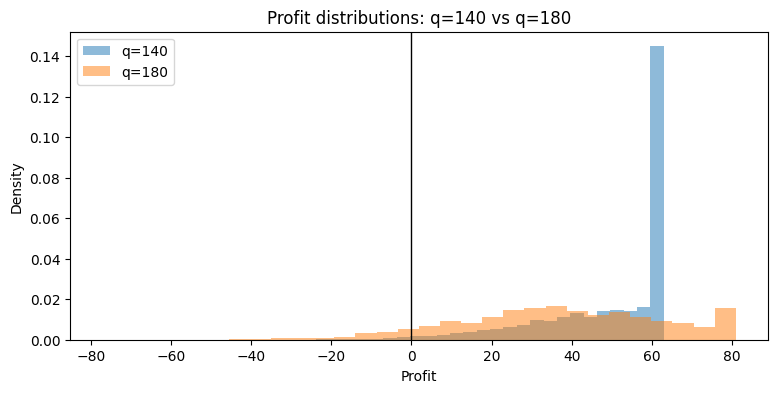

In [3]:
plt.figure(figsize=(9, 4))
plt.hist(profits_140, bins=30, alpha=0.5, label='q=140', density=True)
plt.hist(profits_180, bins=30, alpha=0.5, label='q=180', density=True)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Profit')
plt.ylabel('Density')
plt.title('Profit distributions: q=140 vs q=180')
plt.legend()
plt.show()


## 2. Comparing two alternatives: the trouble with independent runs

Session 3 ended by comparing `q` values using **independent** simulation runs for each. This is the natural first instinct, but it has a hidden cost: any difference we observe between two order quantities is mixed together with simulation noise from *both* runs, since each used different random demand draws.

Let's make this precise. Suppose we want to know: is `q=140` or `q=160` more profitable, and by how much?


In [4]:
n_reps = 500

# Independent runs: separate random draws for each q
profits_140_indep, _ = simulate_newsvendor(140, n_reps, rng)
profits_160_indep, _ = simulate_newsvendor(160, n_reps, rng)

diff_indep = profits_140_indep.mean() - profits_160_indep.mean()

# Standard error of a difference between two INDEPENDENT sample means
se_indep = np.sqrt(profits_140_indep.var(ddof=1) / n_reps + profits_160_indep.var(ddof=1) / n_reps)
t_crit = stats.t.ppf(0.975, df=n_reps - 1)
ci_half_width_indep = t_crit * se_indep

print(f"Independent comparison: mean(q=140) - mean(q=160) = {diff_indep:.3f}")
print(f"95% CI half-width: {ci_half_width_indep:.3f}")
print(f"95% CI: [{diff_indep - ci_half_width_indep:.3f}, {diff_indep + ci_half_width_indep:.3f}]")


Independent comparison: mean(q=140) - mean(q=160) = 3.910
95% CI half-width: 2.472
95% CI: [1.438, 6.382]


## 3. Common Random Numbers: a sharper comparison

**The idea behind CRN:** if we use the *same* sequence of random demand draws for both `q=140` and `q=160`, then on any given simulated "day," both policies face the same realized demand. Differences we observe are then driven *only* by the difference in decision (`q`), not by one policy getting luckier demand draws than the other.

This turns an **independent-samples** comparison into a **paired** comparison — and paired comparisons are almost always more precise when the two things being compared are positively correlated, which they usually are here (both policies do well on high-demand days and both do poorly on very low-demand days).


In [5]:
def simulate_newsvendor_from_demand(q, demand):
    # Same profit calculation as before, but demand is passed in directly.
    sold = np.minimum(q, demand)
    scrap = q - sold
    profit = r * sold + s * scrap - c * q
    return profit

# CRN: draw ONE stream of demand, reuse it for both policies
rng_crn = np.random.default_rng(seed=42)
shared_demand = np.maximum(rng_crn.normal(mu_demand, sigma_demand, size=n_reps), 0)

profits_140_crn = simulate_newsvendor_from_demand(140, shared_demand)
profits_160_crn = simulate_newsvendor_from_demand(160, shared_demand)

# Paired differences -- one per simulated day, using the SAME demand for both policies
paired_diffs = profits_140_crn - profits_160_crn

mean_diff_crn = paired_diffs.mean()
se_crn = paired_diffs.std(ddof=1) / np.sqrt(n_reps)
ci_half_width_crn = stats.t.ppf(0.975, df=n_reps - 1) * se_crn

print(f"CRN (paired) comparison: mean(q=140) - mean(q=160) = {mean_diff_crn:.3f}")
print(f"95% CI half-width: {ci_half_width_crn:.3f}")
print(f"95% CI: [{mean_diff_crn - ci_half_width_crn:.3f}, {mean_diff_crn + ci_half_width_crn:.3f}]")

print(f"\nCI half-width, independent sampling: {ci_half_width_indep:.3f}")
print(f"CI half-width, CRN (paired):          {ci_half_width_crn:.3f}")
print(f"Variance reduction factor: {(ci_half_width_indep / ci_half_width_crn):.2f}x narrower")


CRN (paired) comparison: mean(q=140) - mean(q=160) = 4.931
95% CI half-width: 0.676
95% CI: [4.255, 5.607]

CI half-width, independent sampling: 2.472
CI half-width, CRN (paired):          0.676
Variance reduction factor: 3.66x narrower


The CRN-based confidence interval should be noticeably **narrower** than the independent-sampling one, even though both used the same number of replications. That's the practical payoff: **CRN lets you draw sharper conclusions from the same simulation budget.** We'll formalize exactly why this works (positive correlation between paired outputs reduces the variance of the *difference*) and explore other variance-reduction techniques in Session 10.

### Discussion: when would CRN *not* help?

CRN's benefit relies on the two systems being **positively correlated** under shared randomness. Can you think of a comparison where using the same random numbers for both alternatives might *not* induce much correlation (and therefore wouldn't help much)?


## Exercise (guided): a risk-aware, CRN-based scenario comparison

Marketing is proposing a promotional campaign that would shift the demand distribution to `Normal(150, 27.1)` (higher mean, same variability). Management wants to know: **for the current order quantity `q=140`, how much would profit improve under the promotion, and is the promotion worth it from a risk perspective too?**

Your task:

1. Using CRN (one shared stream of *standard normal* draws, scaled appropriately to each scenario's mean/std), simulate profit at `q=140` under (a) the current demand distribution and (b) the promotional demand distribution
2. Compute the paired difference in profit and its 95% CI
3. Compute risk metrics (Section 1) for both scenarios and compare
4. State, in a sentence or two, whether the promotion looks like a good idea purely from this profit/risk comparison (setting aside the campaign's own cost, which isn't modeled here)

**Hint:** to correctly apply CRN when two scenarios have *different* distributions, draw one stream of standard normal values `z ~ Normal(0, 1)` and transform it to each scenario via `mu + sigma * z` — this keeps the same underlying randomness driving both, even though the resulting demand distributions differ.


In [6]:
# EXERCISE
n_reps = 1000
rng_promo = np.random.default_rng(123)

# TODO: draw ONE shared stream of standard normal values z, length n_reps

# TODO: build demand_current = mu_demand + sigma_demand * z  (clip at 0)
# TODO: build demand_promo   = 150 + sigma_demand * z         (clip at 0)

# TODO: compute profits at q=140 for both demand streams using simulate_newsvendor_from_demand

# TODO: compute the paired difference (promo - current), its mean, and its 95% CI

# TODO: compute risk_metrics() for both profit series and compare

# TODO: print a one-to-two sentence conclusion


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
n_reps = 1000
rng_promo = np.random.default_rng(123)

z = rng_promo.standard_normal(n_reps)

demand_current = np.maximum(mu_demand + sigma_demand * z, 0)
demand_promo = np.maximum(150 + sigma_demand * z, 0)

profits_current = simulate_newsvendor_from_demand(140, demand_current)
profits_promo = simulate_newsvendor_from_demand(140, demand_promo)

paired_diff = profits_promo - profits_current
mean_diff = paired_diff.mean()
se_diff = paired_diff.std(ddof=1) / np.sqrt(n_reps)
half_width = stats.t.ppf(0.975, df=n_reps - 1) * se_diff

print(f"Mean profit improvement from promotion: {mean_diff:.3f}")
print(f"95% CI: [{mean_diff - half_width:.3f}, {mean_diff + half_width:.3f}]")

metrics_current = risk_metrics(profits_current)
metrics_promo = risk_metrics(profits_promo)
print(pd.DataFrame([metrics_current, metrics_promo], index=['current', 'promo']).round(2))

print("\nConclusion: the promotion's confidence interval for the profit improvement "
      "excludes zero, so the higher demand appears to genuinely increase expected profit "
      "at q=140 -- and risk metrics (std, VaR, CVaR) should be checked to confirm the "
      "promotion doesn't meaningfully worsen downside risk before recommending it.")
```
</details>


### Discussion questions

1. Why did we scale the *same* `z` values differently for the two scenarios (`mu_demand + sigma_demand * z` vs `150 + sigma_demand * z`) instead of just drawing two separate `Normal()` samples? What would we have lost by drawing them separately?
2. If the promotional campaign itself costs money to run, how would you incorporate that into this comparison? Does the paired CI from step 2 alone tell management whether to run the campaign?
3. Look back at your risk metrics comparison. Is it possible for a decision to have *higher* expected profit but *worse* risk (e.g. higher probability of loss)? What would you tell a risk-averse decision-maker in that case?


## Wrap-up

Today we:

- Went beyond the mean: computed standard deviation, probability of loss, VaR, and CVaR directly from simulation output
- Diagnosed the problem with comparing alternatives via independent simulation runs (noisy, wide CIs on the difference)
- Introduced Common Random Numbers as a way to pair outcomes and sharpen comparisons — and empirically observed the resulting variance reduction
- Applied both risk quantification and CRN together in a realistic scenario-comparison exercise

**Next session:** Flow Analysis & Queueing Theory for Simulation — we shift from "one-shot" Monte Carlo decisions to systems that evolve over time, building the analytical (formula-based) grounding in queueing theory that we'll later use to verify our first Discrete-Event Simulation models in Session 6.
